`Дисциплина: Методы и технологии машинного обучения`   
`Уровень подготовки: бакалавриат`   
`Направление подготовки: 01.03.02 Прикладная математика и информатика`   
   




# Лекция №1: Машинное обучение "без учителя". Задача кластеризации. 

Содержание:

* напоминание специфики задач обучения
* постановка задачи кластеризации
* метрики в задачах кластеризации
* алгортимы иерархической и неиерархической кластеризация

В практических примерах ниже показано:   

* как пользоваться инструментами визуального анализа для предварительной интерпретации кластеров 
* как проводить кластерный анализ 
* как строить прогноз принадлежности к кластерам новых наблюдений
* как оценивать точность кластеризации

*Модели*: иерархический и неиерархический кластерный анализ
*Данные*: 

# Специфика задач машинного обучения

**Задача машинного обучения** - это задача построения алгоритма решения некоторой проблемы по известному набору прецедентов. То есть на основе известного накопленного опыта мы должны научиться принимать некоторые решения в ситуациях, которые мы никогда не встречали.

Цель машинного обучения - предложить такой алгоритм $A(x)$, который будет очень сильно похож на скрытый закон поведения реальных объектов, которые мы исследуем. 

Модель - это *семейство* функций, зависящих от некоторых параметров, из которых мы будем выбирать наш алгоритм.

Наилучшая из всех возможных функций и будет нашей решающей функцией (алгоритмом).

По типу поставленной перед нами задачи, а также по виду исходных данных машинное обучение делится на 3 ветви:

- Машинное обучение с учителем (supervised learning)
- Машинное обучение без учителя (unsupervised learning)
- Машинное обучение с подкреплением (reinforcement learning)



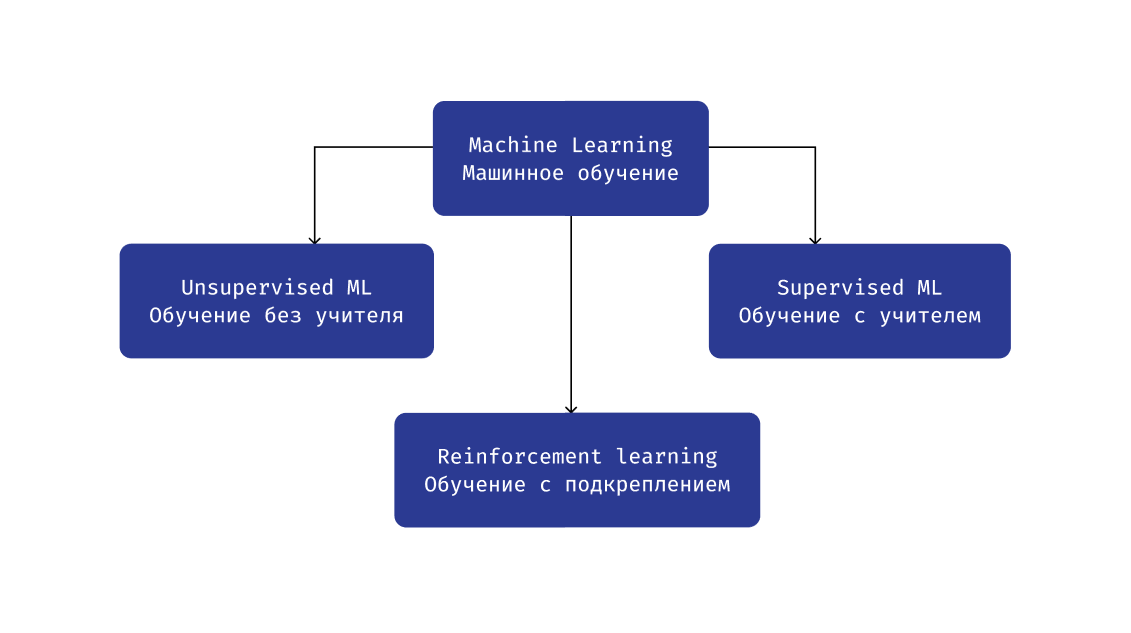

## Машинное обучение с учителем

В этой постановке в качестве обучающей выборки нам дается совокупность некоторых объектов, каждый из которых мы можем каким-то образом численно описать. К каждому из этих объектов *задан некоторый вопрос*, а в обучающей выборке известны ответы на этот вопрос. Цель алгоритма состоит в том, чтобы по обучающей выборке понять, каким образом по описанию объекта можно дать ответ на заданный заранее вопрос.

Если говорить формально,

Обучающая выборка $D = \{(x_i, y_i)\}$ состоит из пар объект $x_i$ - метка $y_i$ и существует некий **закон природы**, 
который связывает $x$ и $y$: $f(x_i) = y_i$

Мы этот закон природы не знаем, но хотим, чтобы наш алгоритм *догадался*, что же это за закон, то есть хотим построить такой алгоритм $A$, чтобы $A(x) = f(x)$ для всех объектов $x$, какие мы только можем найти в природе.











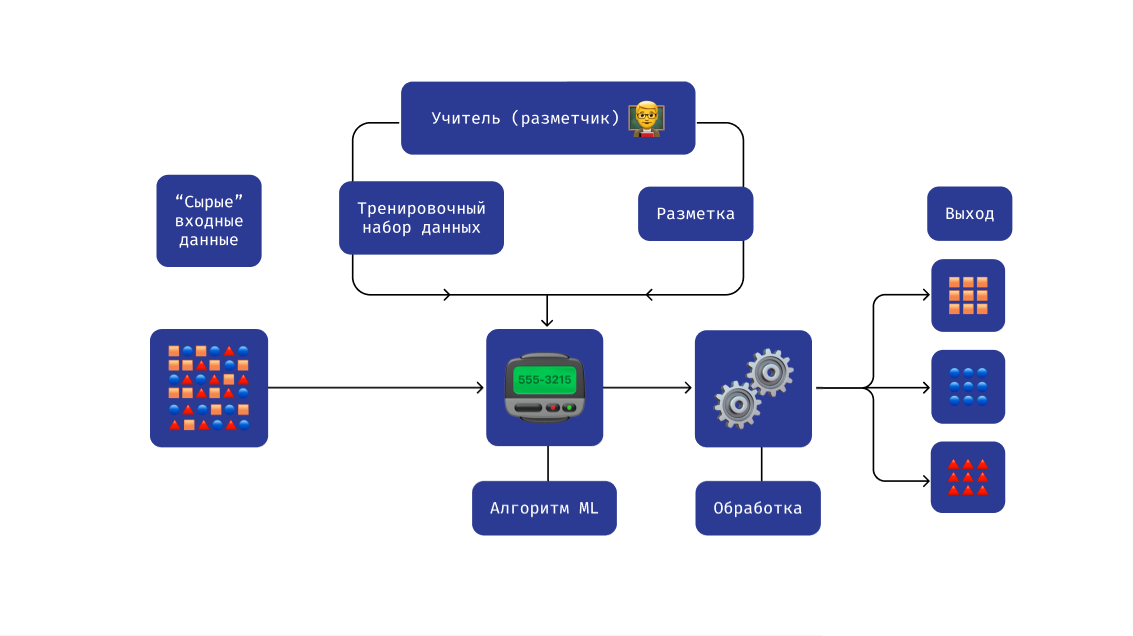

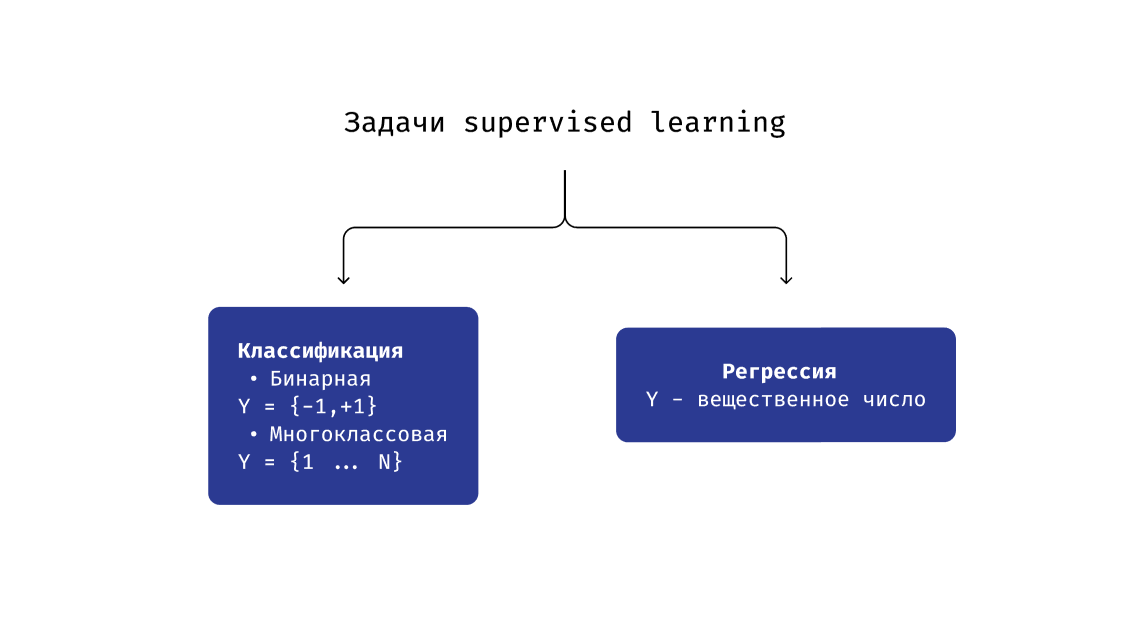

Обучение с учителем делится в свою очередь на ряд различных задач.
В прошлом семестре мы сосредоточились на двух:
задача построения регрессии и задача классификации.

Ключевое отличие этих задач состоит в том, что мы пытаемся предсказать.

### Задача классификации

Наша задача - расфасовать имеющиеся объекты по нескольким группам или классам. Эти классы могут быть самые разные, но у них есть общая черта: метка $y$ для каждого из объектов принадлежит некоторому **конечному множеству**.
То есть мы выбираем одну из $N$ меток для каждого объекта $x$.

**Примеры:**
* Классификация текстов на позитивные и негативные
* Фильтр спама
* Классификация рукописных цифр на изображениях
* Определение жанра картины

### Задача регрессии: 

Наша задача - предсказать некоторое значение, взятое из определенного промежутка. То есть $y_i \in [a,b], a,b \in R$

**Примеры:**
* Предсказание курса валют
* Предсказание среднего времени пути от одной точки на карте до другой
* Предсказание стоимости аренды дома

## Машинное обучение без учителя

В случае задачи обучения без учителя, мы имеем неразмеченный набор данных. Это значит, что мы не задаем никаких вопросов к нашей выборке и не получаем никаких ответов. Мы лишь хотим структурировать нашу выборку, получить из нее какую-то информацию о том, как она устроена.




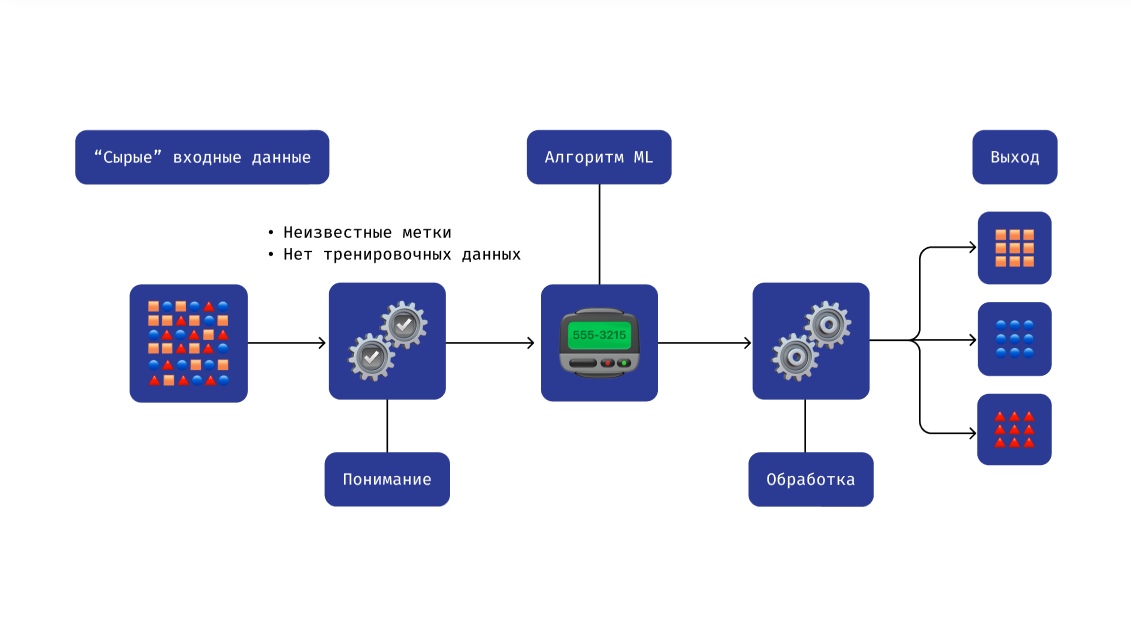

Здесь нас также интересуют две отдельные задачи.

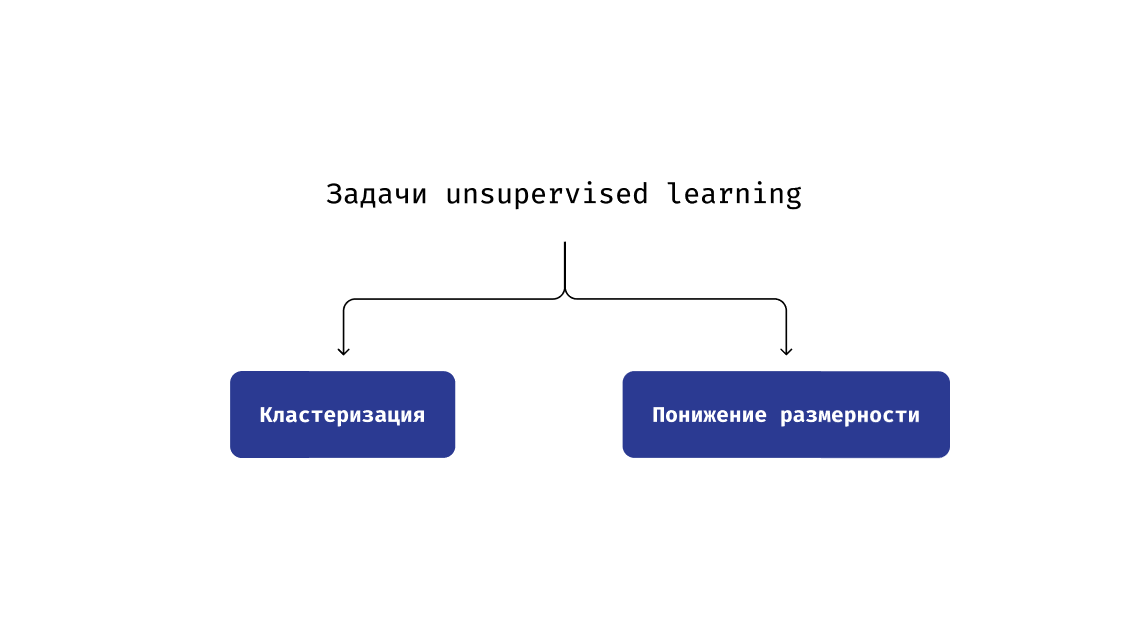

### Задача кластеризации

Пусть нам дан массив объектов. Наша задача - выделить кластерную структуру в этом массиве. Мы предполагаем, что в наборе данных есть несколько групп объектов, внутри каждой из которых все объекты по какому-то признаку похожи друг на друга, а между собой - отличаются.

**Примеры:**
  * Задача кластеризации часто подменяет задачу классификации (заметьте, что задачи по существу чем-то похожи). Например, когда есть несколько классов объектов, притом объекты разных классов существенно отличаются друг от друга, мы можем не проводить разметку данных, а вместо этого воспользоваться алгоритмом кластеризации.
* Например, кластеризация текстов по тематическим кластерам,
* Или же картинок по изображенным на них объектам.



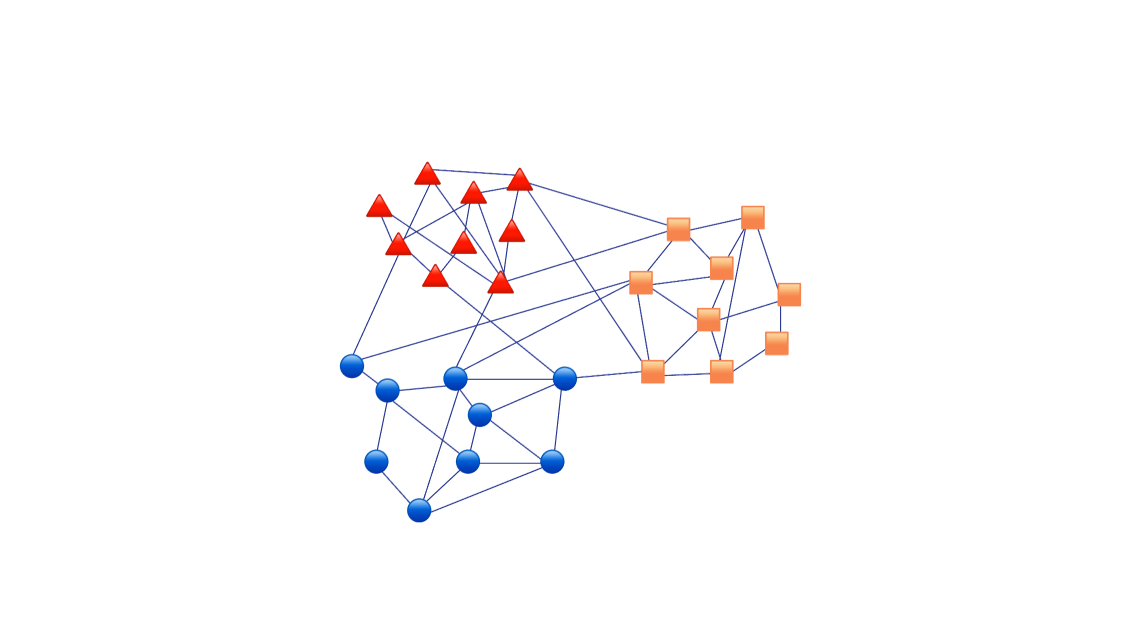

### Задача снижения размерности

Эта задача обладает несколько непрозрачным смыслом: она очень часто встречается в различных информационных системах, как элемент сжатия информации и борьбы с "проклятием размерности". Сейчас мы не будем подробно останавливаться на обсуждении этой задачи, но мы обязательно встретим ее в рамках нашего курса и обсудим некоторые методы ее решения.


## Типы признаков
### 1. Бинарные признаки

Бинарные признаки - это признаки, которые могут принимать лишь 2 значения. Пример такого признака - биологический пол (мужчина и женщина), северное или южное полушарие и т.д.

Такие признаки обычно помечают комбинацией значений 0 и 1, либо -1 и 1

### 2. Категориальные признаки

Отличие от бинарных состоит в том, что категориальные признаки могут принимать значения из некоторого конечного множества. 

Категориальные признаки и сами делятся на 2 класса: *номинальные* и *ранговые*.

В случае номинальных признаков, в отличие от ранговых, не имеет места сравнение их друг с другом, за исключением сравнения на равенство. 

Категориальные признаки могут быть закодированы при помощи нумерации исходного признакового пространства.

### 3. Непрерывные

Это число будет принадлежать некоторому диапазону, то есть будет взято из непрерывного подмножества множества действительных чисел.

### Дополнительные категории
#### 4. Географические данные - координаты широты и долготы

Специфичны и используются довольно редко. Они обычно возникают в задачах, непосредственно связанных с логистикой. 

#### 5. Данные о дате и времени

Специальный формат данных для описания времени наступления некоторого события, либо же его длительности. Удобен дл работы с временными рядами, индексированием данных при помощи времени и т.п. 

# Кластеризация

Кластеризация - это разделение исходного набора **неразмеченных** данных на несколько групп, которые называются кластерами. Кластер - довольно нестрогое понятие. Отличительным признаком кластера можно считать следующее утверждение:

"Среднее расстояние между объектами кластера существенно меньше, чем среднее расстояние между парами объектов, один из которых принадлежит кластеру, а другой - нет".

Поставим эту задачу формально.
_____________________________________
**Дано:**

Пусть $X$ - это пространство объектов, из которых мы набираем обучающую выборку.

$X^N$ = $\{x^i\}_{i=1}^N$- обучающая выборка. Еще раз обратим внимание на то, что в выборке отсутствуют метки $y$.

$\rho: X × X → [0,∞)$ - функция расстояния между объектами.

**Найти:**

$y_i \in Y$ - метки принадлежности кластерам объектов. Требования к ним:

* Каждый кластер состоит из близких объектов.
* Объекты разных кластеров далеки друг от друга.

Пусть  мы можем определить $\textbf{близость}$ объекта $X$ к каждому из объектов $x_i$, то есть мы знаем функцию близости (*метрику*) $\rho(x,y)$, обладающую следующими свойствами:
$$1. \rho(x,x) = 0, \rho(x,y) > 0$$
$$2. \rho(x,y) = \rho(y,x)$$
$$3. \rho(x,z) \leq \rho(x,y) + \rho(y,z)$$

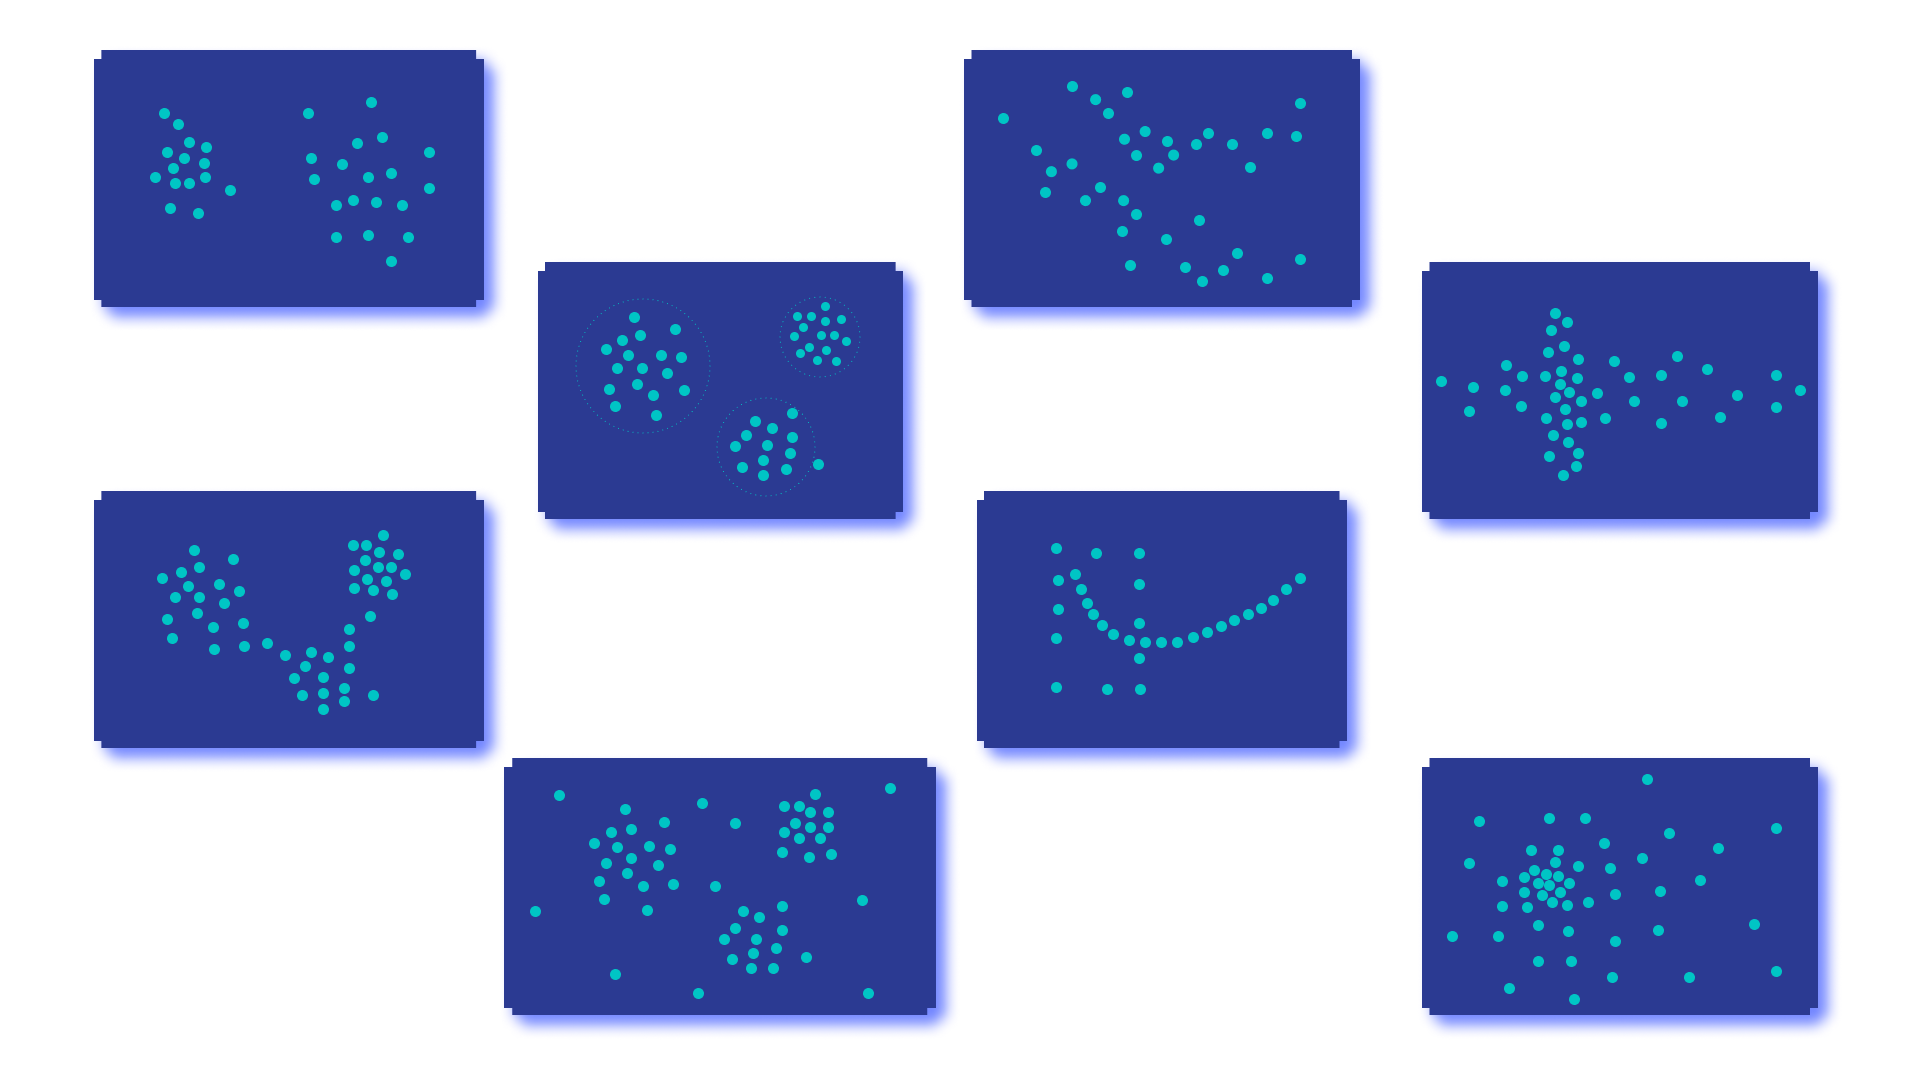

Выбор метрики $\rho(x,y)$ в пространстве объектов $X$ - это довольно серьёзная проблема. Метрику также можно настраивать по обучающей выборке.

В следующих определениях введены такие обозначения:

$x$ и $y$ здесь - это точки много мерного пространства $X$, в котором мы работаем. Каждая из этих точек представлена свои векторным описанием: $x = (x_1 ... x_n)$ и $y = (y_1 ... y_n)$.

1. Евклидово расстояние
$$\rho(x,y) = (\sum\limits_{i=1}^n(x_i - y_i)^2)^{\frac{1}{2}}$$

2. Косинусная схожесть
$$\rho^*(x,y) = \frac{(x,y)}{|x||y|} = \frac{\sum\limits_{i=1}^n{x_i}{y_i}}{|x||y|}$$

3. Расстояние городских кварталов (Манхэттенское)
$$\rho(x,y) = \sum\limits_{i=1}^n|x_i - y_i|$$

4. Квадрат евклидова расстояния
$$\rho(x,y) = \sum\limits_{i=1}^n(x_i - y_i)^2$$

5. Расстояние Чебышева
$$\rho(x,y) = \max|x_i - y_i|$$


и др.

# Иерархическая кластеризация
______________________________________
Иерархическая кластеризация предполагает два различных глобальных подхода - *аггломеративная иерархическая кластеризация* и *дивизионная*. Отличия между ними состоят в том, что аггломеративная кластеризация предполагает последовательное слияние различных кластеров, в то время как дивизионная - последовательное разбиение. В этой лекции мы будем обсуждать аггломеративную кластеризацию.
______________________________________


Идея иерархической кластеризации состоит в последовательном проведении некоторой итерационной процедуры (то есть процедуры, состоящей из некоторого количества повторяющихся шагов), позволяющей на основе известного разбиения на $N$ кластеров провести слияние наиболее близких из них (или же наоборот, разбить один из кластеров на 2 разных) получив разбиение на $N-1$ кластер (или же на $N+1$). Таким образом, мы получим последовательность разбиений на разное число кластеров нашей выборки и выберем наилучшее из них.

## Алгоритм иерархической кластеризации

Алгоритм, позволяющий проводить последовательное слияние кластеров при условии, что мы имеем некоторую функцию, позволяющую измерить расстояние между двумя кластерами. Назовем эту функцию $R(U,V)$, где $U$ и $V$ - некоторые кластеры.

> 1. Пусть сначала все кластеры одноэлементные. То есть каждый объект нашей выборки представляет собой в начальном приближении отдельный кластер. Важно помнить, что если данные представлены в разных единицах измерения, их первоначально необходимо стандартизировать.
> 2. Повторим слеющий пункт $L-1$ раз, где $L$ - размер нашей выборки:
> 3. Найдем два ближайших кластера в нашей структуре, согласно значению функции $R(U, V)$, и сольем их в один кластер. Обозначим найденную кластерную структуру на данном шаге $t$ как $C_t$,

На выходе этого алгоритма получим последовательность разбиений на кластеры $C_1 ... C_L$, где разбиение $C_1$ - тривиальное разбиение на индивидуальные кластеры, $C_2$ - разбиение на $L-1$ индивидуальный кластер и 1 кластер, содержащий 2 точки и т.д., а $C_L$ - тривиальное разбиение на один единственный кластер, содержащий все объекты.

Для удобства визуализации такого варианта кластеризации часто используют специальную диаграмму, называемую **дендрограммой**.

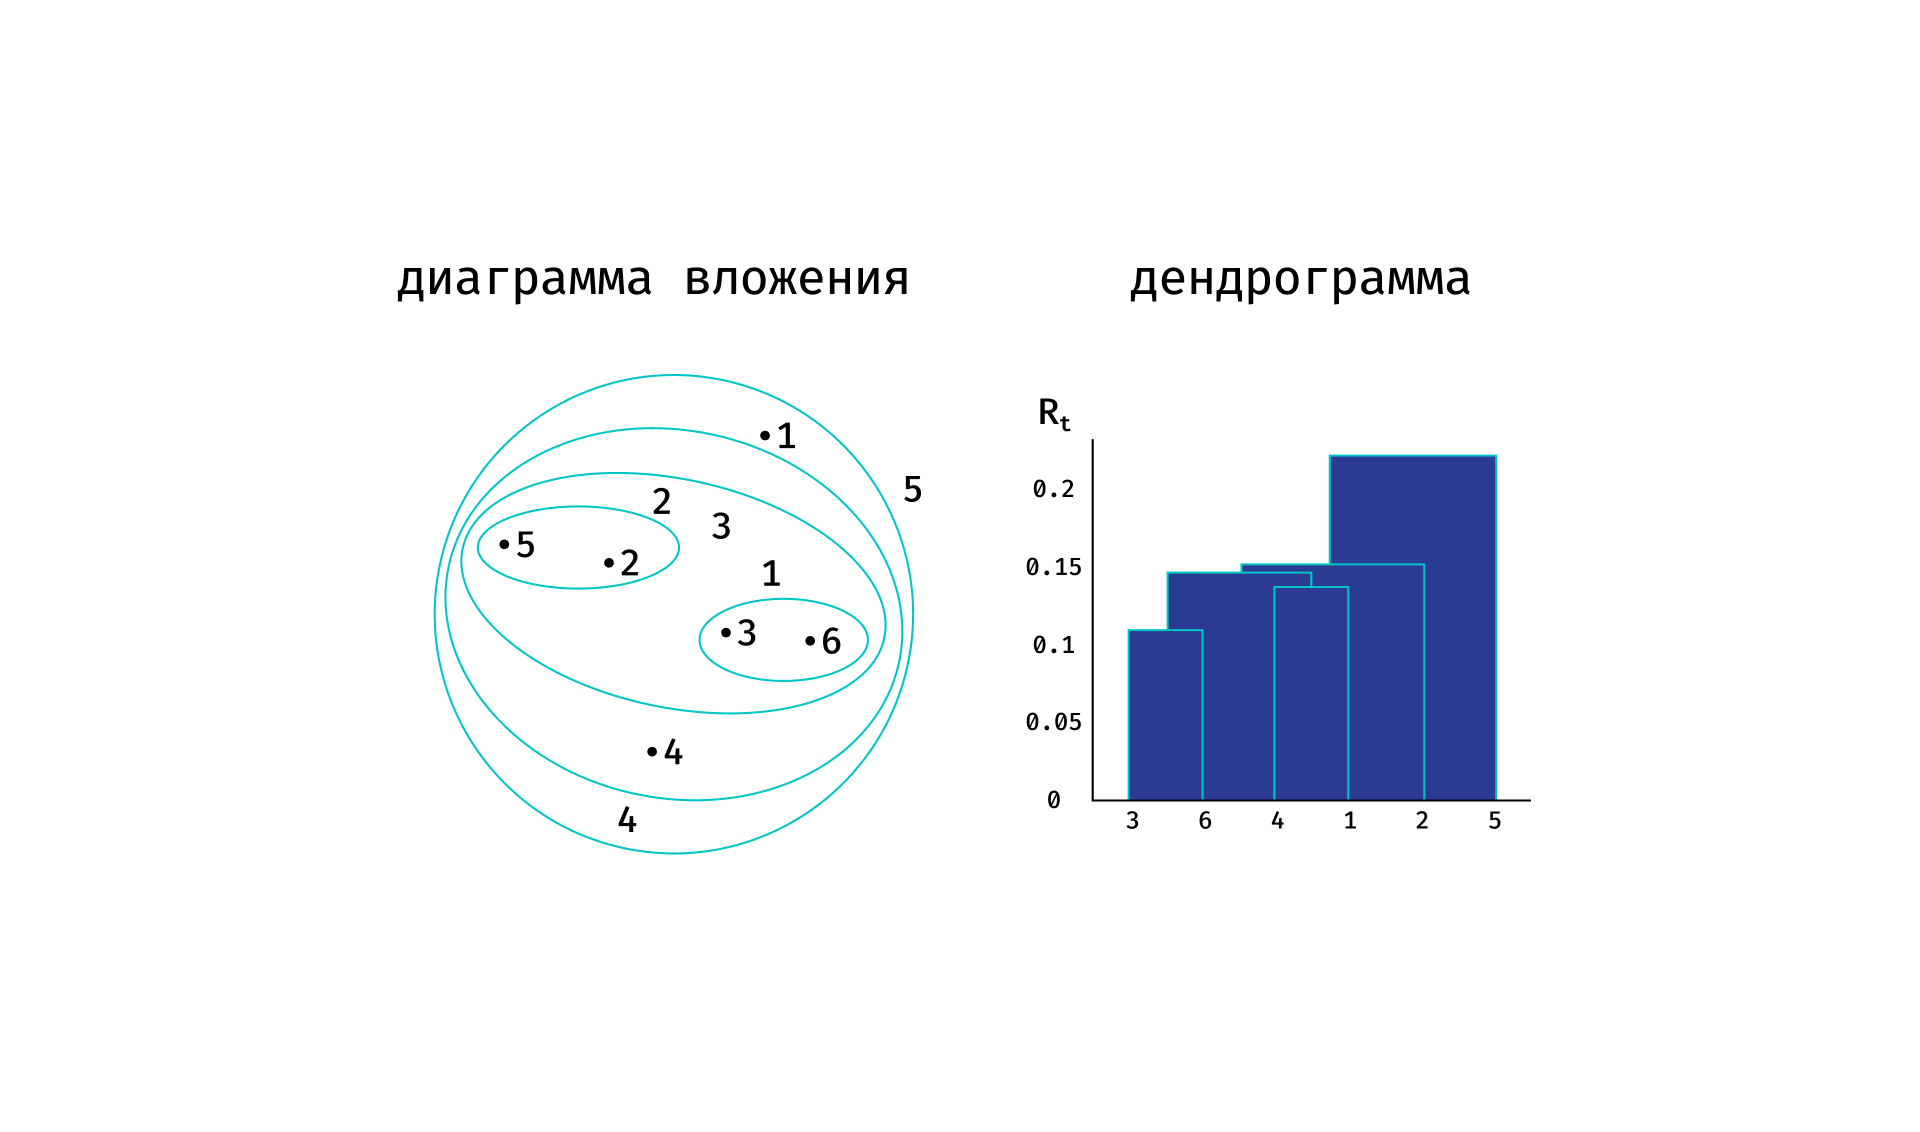

Существует довольно много различных алгоритмов объединения (или, наоборот, разделения) элементов по кластерам.
Например,
* Расстояние ближайшего соседа. $R(U, V)$ = $\min\limits_{x \in U, y \in V}(\rho(x,y))$
* Расстояние дальнего соседа. $R(U, V)$ = $\max\limits_{x \in U, y \in V}(\rho(x,y))$
* Среднее групповое расстояние. $R(U, V)$ = $\frac{1}{N}\sum\limits_{x \in U, y \in V}(\rho(x,y))$

Формула **Ланса-Уильямса** позволяет в общем виде формализовать эти алгоритмы.

Будем считать, что кластер $W$ = $U \bigcup V$. Будем также считать, что мы знаем расстояния между кластерами $R(U, S)$ и $R(V, S)$.

Тогда $$R(W, S) = α_U\times R(U,S) + α_V\times R(V,S) + β\times R(U,V) + γ\times |R(U,S) - R(V,S)|$$

Необходимо выбрать коэффициенты $α_U, α_V, β, γ$ - от этого зависит алгоритм.

Например, если мы положим $α_U = α_V = \frac{1}{2}, β=0, γ=-\frac{1}{2}$, то мы получим формулу для расстояния ближайшего соседа.
А при наборе коэффициентов $α_U = α_V = \frac{1}{2}, β=0, γ=\frac{1}{2}$ получим расстояние дальнего соседа.

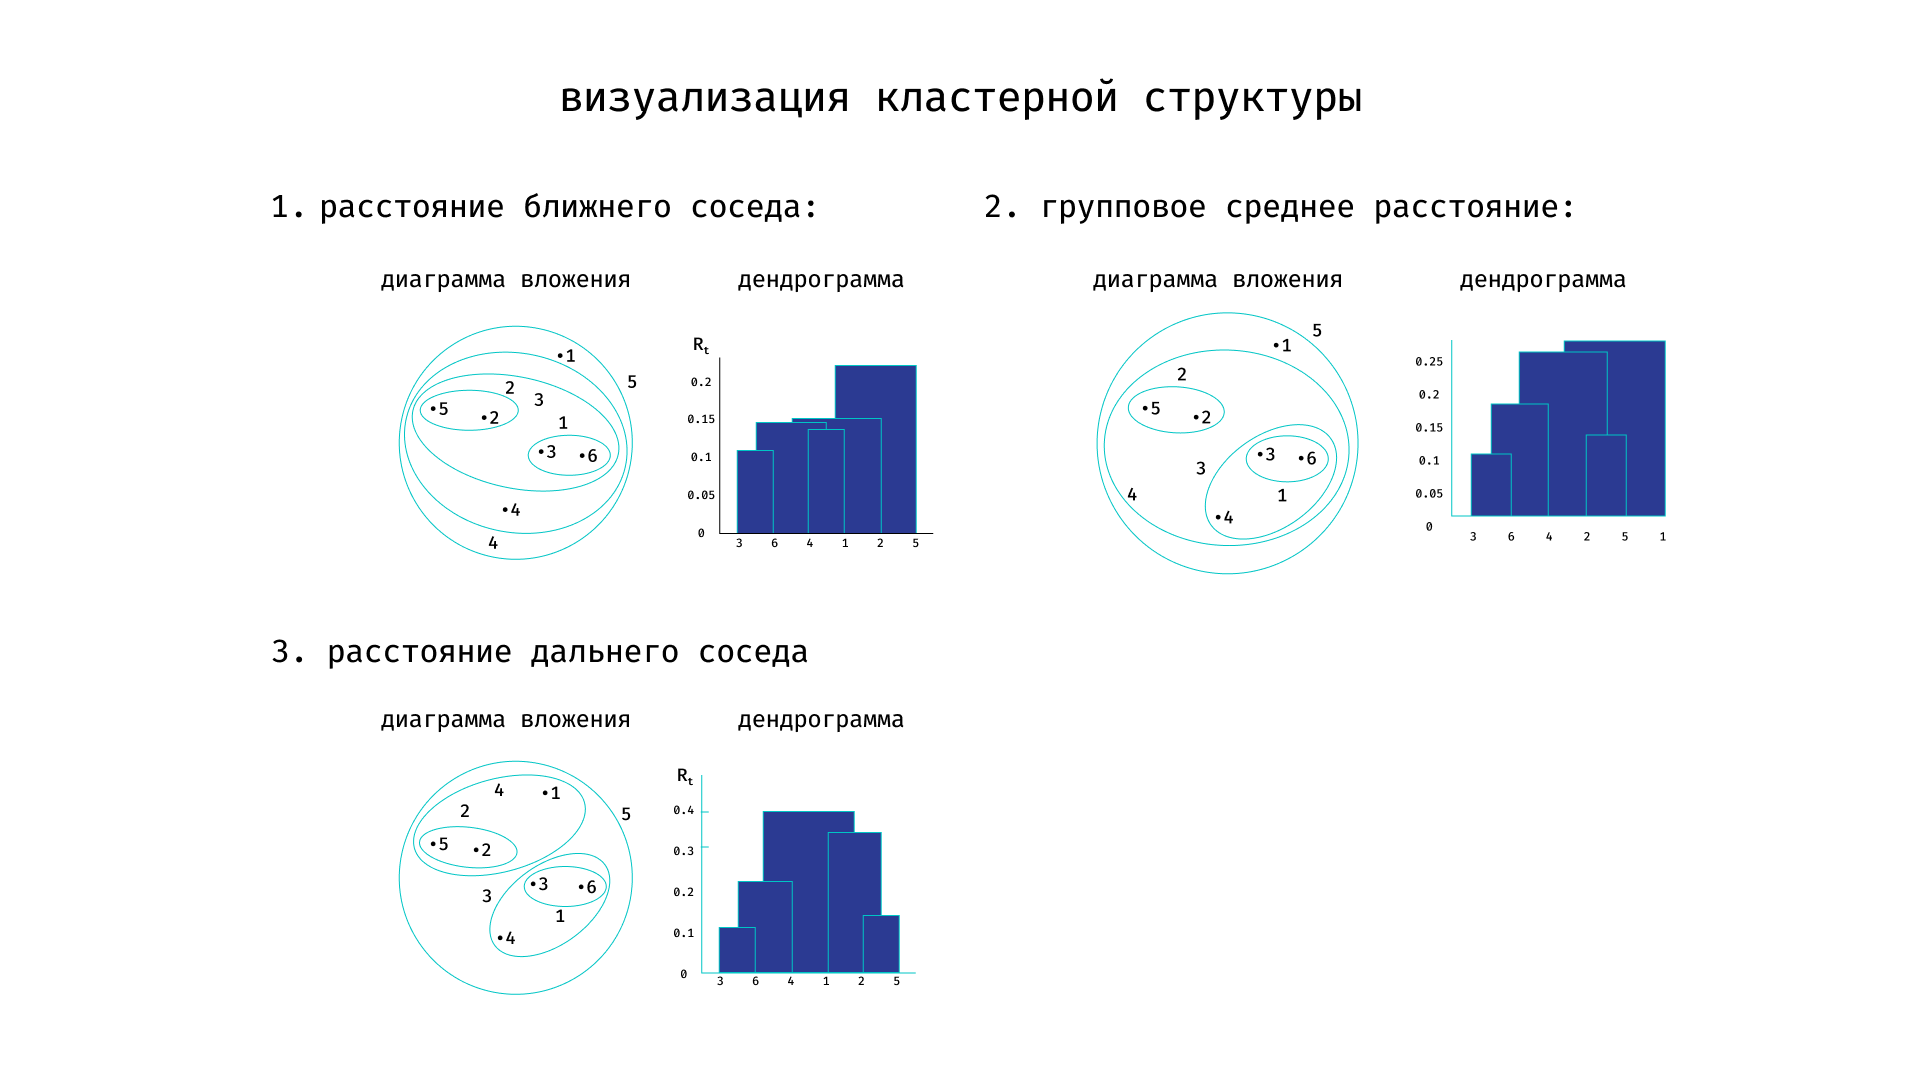

## Реализация в Python
#### Импорт пакетов

In [1]:
import numpy as np
import pandas as pd
# процедура стандартизации
from sklearn.preprocessing import StandardScaler
# алгоритм k-средних
from sklearn.cluster import KMeans
# алгоритм k-ближайших соседей
from sklearn.neighbors import KNeighborsClassifier
# дендрограмма
from scipy.cluster.hierarchy import dendrogram, linkage
# дендрограмма, расчет матрицы расстояний
from scipy.spatial.distance import pdist
# метрики
from sklearn import metrics 
# кластерные силуэты
from matplotlib import cm 
from sklearn.metrics import silhouette_samples
from matplotlib import pyplot as plt
import seaborn
seaborn.set_theme()

Разберем на небольшом примере, чтобы удобнее было строить дендрограмму

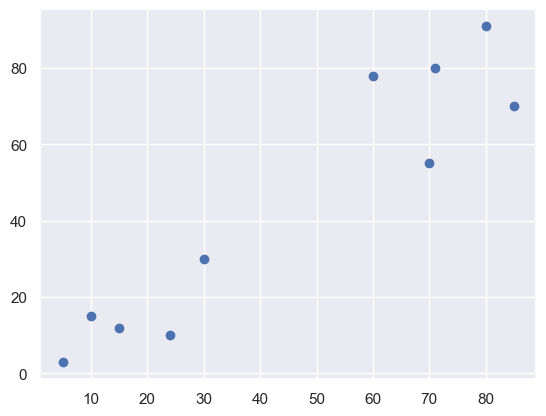

In [2]:
X = np.array([[5,3],
    [10,15],
    [15,12],
    [24,10],
    [30,30],
    [85,70],
    [71,80],
    [60,78],
    [70,55],
    [80,91],])

plt.scatter(X[:,0],X[:,1])

In [3]:
row_clusters = linkage(X, method= 'complete', metric= 'euclidean') 
# посмотрим на результаты внимательнее
res = pd.DataFrame(row_clusters, 
                   columns= [ 'метка_строки_1', 'метка_строки_2', 'расстояние', 'число_элементов'], 
                   index = ['кластер %d ' %(i+1) for i in range (row_clusters.shape[0] ) ] )
res

,метка_строки_1,метка_строки_2,расстояние,число_элементов
кластер 1,1.0,2.0,5.830952,2.0
кластер 2,6.0,7.0,11.180340,2.0
кластер 3,0.0,10.0,13.453624,3.0
кластер 4,3.0,12.0,20.248457,4.0
кластер 5,5.0,8.0,21.213203,2.0
кластер 6,9.0,11.0,23.853721,3.0
кластер 7,4.0,13.0,36.796739,5.0
кластер 8,14.0,15.0,37.363083,5.0
кластер 9,16.0,17.0,115.624392,10.0


Матрица связей состоит из нескольких строк, где каждая строка представляет одно объединение. Первый и второй столбцы обозначают наиболее различающихся членов в каждом кластере, и третий столбец сообщает о расстоянии между этими членами. Последний столбец возвращает число наблюдений в каждом кластере. 
Построим далее дендрограмму.

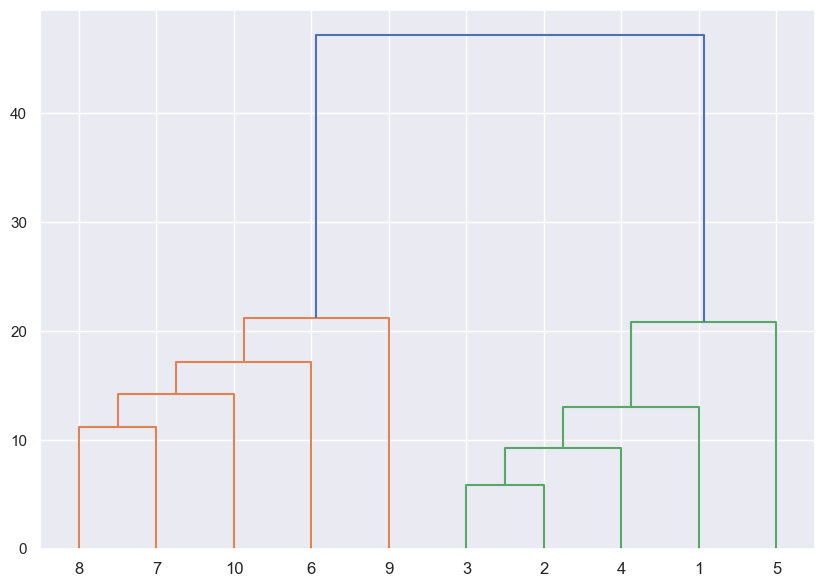

In [4]:
linked = linkage(X, 'single')
labelList = range(1, len(X)+1)

plt.figure(figsize=(10, 7))
dendrogram(linked,
            orientation='top',
            labels=labelList,
            distance_sort='descending',
            show_leaf_counts=True)
plt.show()

# Неиерархическая кластеризация. Метод K-Means (K средних)

Один из самых популярных методов кластеризации называется **k-means**.
Для того чтобы обсудить этот алгоритм, введем понятие *центра кластера*.

**Центр кластера** - это точка, представляющая собой центр масс области, отведенной кластеру (геометрическая середина). 
Центр определяется как среднее по всем точкам для каждой координаты. 

Необходимо иметь предположение о числе кластеров в имеющемся наборе данных. Обозначим его $K$.

Заметим, что искомые кластеры можно однозначно задать в виде $K$ точек в пространстве признаков. 
> Зададимся начальным приближением центров искомых кластеров $\Theta_0 = (\theta_1^0 ... \theta_k^0)$

> Пока не достигнута сходимость:
>> 1.Посчитаем, каким кластерам принадлежат точки имеющегося датасета при условии текущего приближения $G_i$: $g_j^i := \arg\min\limits_{p = 1 ... k}(\rho(Θ_p^{i-1}, x_j))$ для всех $x_j$ из датасета.
>
>> 2. На основе посчитанного распределения датасета по кластерам G = ($g_1^i ... g_N^i $) пересчитаем новые центры кластеров $\Theta_i = (\theta_1^i ... \theta_k^i)$.

Мы будем понимать под сходимостью ситуацию, при которой каждый следующий шаг приводит к крайне незначительному изменению нашей оценки центров кластеров. В реальности во многих алгоритмах мы задаемся некоторым маленьким числом $ϵ$, а затем сравниваем изменение оценок с этим значением. Если оказалось, что изменение оценок из шага в шаг полуается меньше, чем $ϵ$, мы говорим, что достигли сходимости.

## Выводы:

1. Алгоритм очень сильно зависит от начального приближения центров кластеров. 
2. При неверном заданном числе кластеров мы получаем формально корректный результат, который может быть не вполне правильным отображением реальности.

**Замечание:** Нужно отметить, что K-Means способен обнаруживать лишь достаточно простые кластерные структуры. Например, с определением кольцевых кластеров у него возникнут проблемы, и потребуется использовать другие методы кластеризации.

## Как бороться с обозначенными проблемами?
1. Запуск алгоритма много раз с разными начальными приближениями центров кластеров, а затем выбрать то решение, где сумма расстояний от каждого объекта до центра масс его кластера - наименьшая.

2. Иерархическая кластеризация

## Реализация в Python
Данные в примере:
* **Income** - ежемесячный доход клиента
* **Account** - размер счета в банке клиента
Задача состоит в разделении клиентов на группы в зависимости от этих показателей

In [5]:
fileURL = 'https://raw.githubusercontent.com/ania607/ML/main/data_2/income.csv'
df = pd.read_csv(fileURL)
df.columns = ["Number", "Income", "Account"]
df.head()

,Number,Income,Account
0,0,29508.885351,2.044155e+06
1,1,31529.775874,2.057775e+06
2,2,30245.313333,2.030280e+06
3,3,30527.184538,2.059592e+06
4,4,32106.224120,2.047552e+06


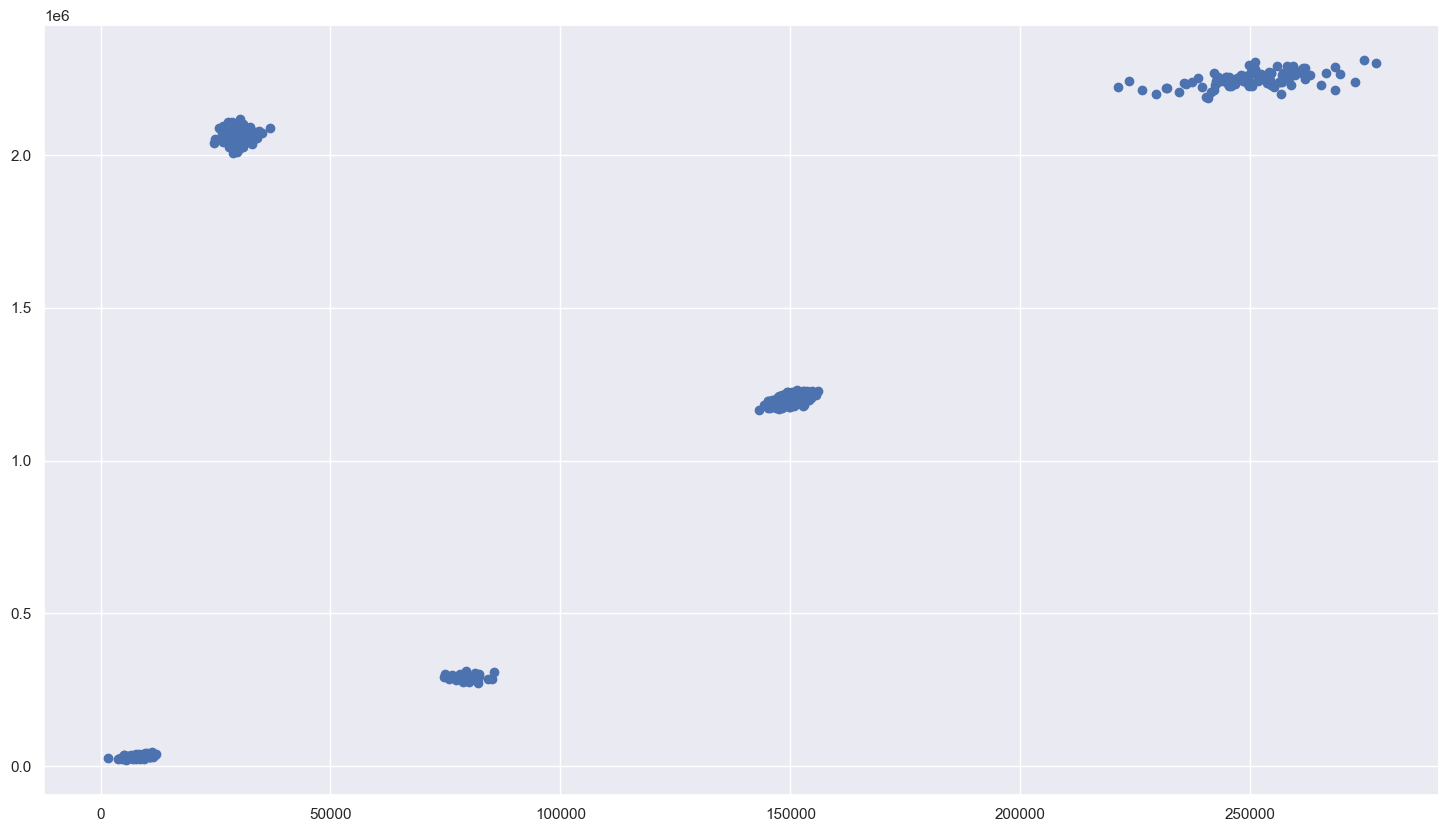

In [6]:
plt.figure(figsize=(18,10))
plt.scatter(df.Income, df.Account)

В нашем примере наблюдения визуально сгруппированы на 5 групп. Тем не менее, рассмотрим метод для определения наилучшего количества кластеров.

#### Напоминание: стандартизация
Формально здесь не требуется, поскольку показатели в одних единицах измерения.

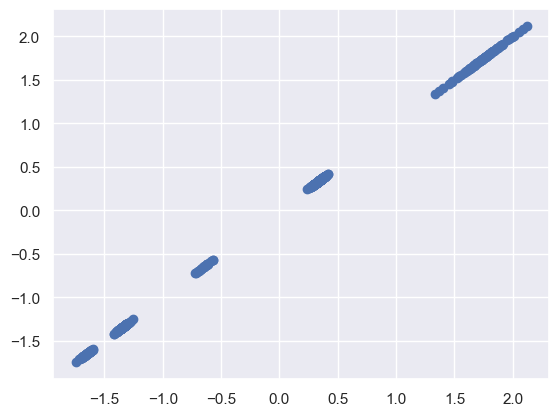

In [7]:
ss = StandardScaler()
std_df = df.drop(columns = 'Number')
std_df = ss.fit_transform(std_df)
# результат - массив
plt.scatter(std_df[:, 0], std_df[:, 0])


#### Определение оптимального количества кластеров для метода локтя

Одна из основных трудностей в обучении без учителя состоит в том, что мы не знаем точного ответа. В нашем наборе данных нет 
установленных данных о метках классов, поэтому для количественного определения качества кластеризации нам нужно использовать внутренние метрики - такие как внутрикластерная **SSE** (искажение или инерция):
$$SSE = \sum\limits_{i=1}^n\sum\limits_{j=1}^kw_{ij}(x_i - m_i)^2$$

Здесь $w_{ij}$ = 1, если наблюдение относится к кластеру $j$ и 0 в противоположном случае, а $m_i$ - центроид кластера.

Основываясь на внутрикластерной SSE, мы можем применить графический инструмент, так называемый метод локтя, для оценки оптимального числа k кластеров для поставленной задачи. Интуитивно мы можем сказать, что если k увеличивается, то искажение уменьшается. Это вызвано тем, что образцы будут ближе к центроидам, которым они назначены. В основе метода локтя лежит идея, которая состоит в том, чтобы идентифицировать значение k в точке, где искажение начинает увеличиваться быстрее всего, что станет понятнее, если мы построим график искажения для разных значений k.

Text(0, 0.5, 'Искажение ')

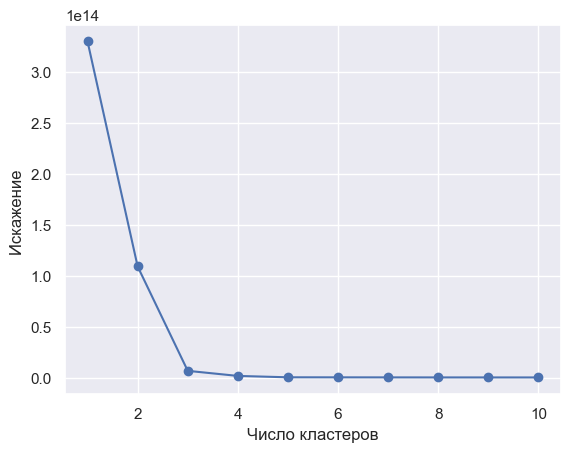

In [60]:
distortions = [] 
#df = df.drop(columns = 'Number')
for i in range (1, 11): 
    km = KMeans(n_clusters=i, 
                init='random', 
                n_init=10 , 
                max_iter=300, 
                random_state=0) 
    km.fit(df)
    distortions.append(km.inertia_) 
plt.plot(range(1, 11) , distortions , marker='o') 
plt.xlabel('Чиcлo кластеров') 
plt.ylabel ('Искажение ' ) 

Как видно на следующем ниже графике, локоть расположен в k = 3, что свидетельствует о том, что k = 3 является хорошим выбором для этого набора данных.

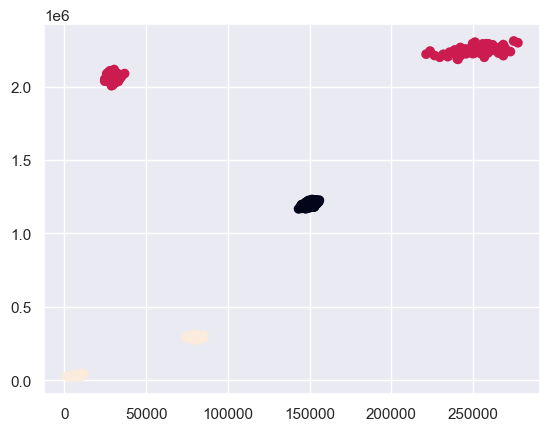

In [12]:
kmeans = KMeans(n_clusters=3,random_state=0).fit(df.values)
plt.scatter(df.Income, df.Account, c=kmeans.labels_)

Тем не менее, визуальный анализ говорит о наличии 5 различных групп. Сделаем и такое построение:

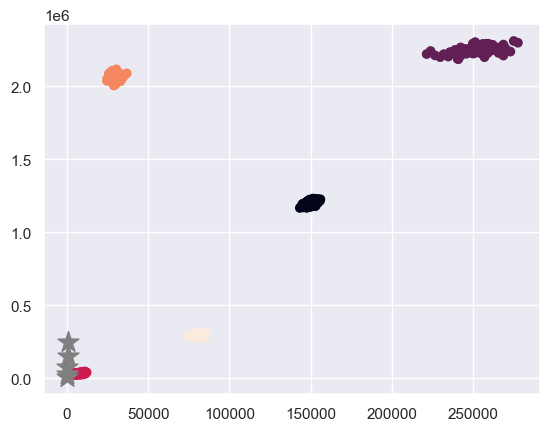

In [11]:
kmeans = KMeans(n_clusters=5,random_state=0).fit(df.values)
plt.scatter(df.Income, df.Account, c=kmeans.labels_)
# нарисуем центроиды
plt.scatter(kmeans.cluster_centers_ [:, 0], kmeans.cluster_centers_ [:, 1], 
           s=250, marker= '*', c = 'grey', label = 'центроиды') 

Теперь видим, что каждая группа точек покрашена в цвет соответствующего кластера, а центроиды расположены внутри множества точек. Тем не менее, попробуем оценить качество кластеризации в обоих вариантах.

#### Количественная оценка качества кластеризации

Задача оценки качества кластеризации является более сложной по сравнению с оценкой качества классификации. Во-первых, такие оценки не должны зависеть от самих значений меток, а только от самого разбиения выборки. Во-вторых, не всегда известны истинные метки объектов, поэтому также нужны оценки, позволяющие оценить качество кластеризации, используя только неразмеченную выборку.

Выделяют *внешние* и *внутренние* метрики качества. Внешние используют информацию об истинном разбиении на кластеры, в то время как внутренние метрики не используют никакой внешней информации и оценивают качество кластеризации, основываясь только на наборе данных. Оптимальное число кластеров обычно определяют с использованием внутренних метрик.


**Adjusted Rand Index (ARI)**

Предполагается, что известны истинные метки объектов. Данная мера не зависит от самих значений меток, а только от разбиения выборки на кластеры. Пусть $N$ - число объектов в выборке. Обозначим через $a$ - число пар объектов, имеющих одинаковые метки и находящихся в одном кластере, через $b$ - число пар объектов, имеющих различные метки и находящихся в разных кластерах. Тогда Rand Index это $$\text{RI} = \frac{2(a + b)}{n(n-1)}.$$ То есть это доля объектов, для которых эти разбиения (исходное и полученное в результате кластеризации) "согласованы". Rand Index (RI) выражает схожесть двух разных кластеризаций одной и той же выборки. Чтобы этот индекс давал значения близкие к нулю для случайных кластеризаций при любом $N$ и числе кластеров, необходимо нормировать его. Так определяется Adjusted Rand Index: $$\text{ARI} = \frac{\text{RI} - E[\text{RI}]}{\max(\text{RI}) - E[\text{RI}]}.$$

Эта мера симметрична, не зависит от значений и перестановок меток. Таким образом, данный индекс является мерой расстояния между различными разбиениями выборки. $\text{ARI}$ принимает значения в диапазоне $[-1, 1]$. Отрицательные значения соответствуют "независимым" разбиениям на кластеры, значения, близкие к нулю, - случайным разбиениям, и положительные значения говорят о том, что два разбиения схожи (совпадают при $\text{ARI} = 1$). 
ARI реализована в `sklearn.metrics`. 

Использовать в данном случае мы его не сможем, поскольку нам неизвестно истинное разбиение. 
Вместо этого показателя можно использовать также привычные меры качества классификации (чувствительность, специфичность, коэффициент точности и др.).

In [13]:
# ПРИМЕР употрбеления
kmeans = KMeans(n_clusters=5,random_state=0).fit(df.values)
# пусть y - истинное разбиение
metrics.adjusted_rand_score(y, kmeans.labels_)

NameError: name 'y' is not defined

**Силуэтный метод**

Еще  одна внутренняя метрика для оценки качества кластеризации (наряду с **SSE**) представлена силуэтным анализом
Силуэтный анализ может использоваться в качестве графического инструмента для построения графика меры плотности группировки образцов в кластерах. 
Чтобы вычислить силуэтный коэффициент наблюдения в нашем наборе данных, можно применить следующие три шага. 
1. Вычислить *внутриклассовую связность* $a_i$ как среднее расстояние между наблюдением и другими точками кластера
2. Вычислить *межкластерное разделение* $b_i$ от следующего ближайшего кластера как среднее расстояние между наблюдением $х_i$ и всеми наблюдениями в ближайшем кластере
3. Вычислить *силуэт* $s_i$:
$$s_i = (b_i - a_i)/\max(b_i,a_i).$$

$s_i$ принимает значения в диапазоне $[-1, 1]$. Идеальное совпадение - когда $s_i = 1.$

Средний коэффициент силуэта --  0.9601675172683456


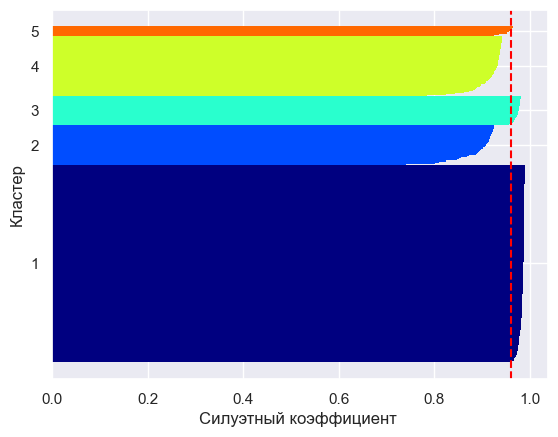

In [85]:
kmeans = KMeans(n_clusters=5,random_state=0).fit(df.values)
# метки кластеров для каждого наблюдения
y_km = kmeans.fit_predict(df) 

cluster_labels = np.unique(y_km) 
n_clusters = cluster_labels.shape[0] 
silhouette_vals = silhouette_samples(df, y_km, metric='euclidean')

# изобразим график силуэтов
y_ax_lower , y_ax_upper = 0, 0 
yticks = [] 
for i, c in enumerate(cluster_labels): 
    c_silhouette_vals = silhouette_vals[y_km == c] 
    c_silhouette_vals.sort() 
    y_ax_upper += len(c_silhouette_vals) 
    color = cm.jet(float(i) / n_clusters) 
    plt.barh(range(y_ax_lower, y_ax_upper), 
             c_silhouette_vals , 
             height=1.0, 
             edgecolor='none', 
             color=color) 
    yticks.append((y_ax_lower + y_ax_upper) / 2) 
    y_ax_lower += len(c_silhouette_vals) 
silhouette_avg = np.mean(silhouette_vals) 
    
plt.axvline(silhouette_avg, color= "red", linestyle="--" ) 
print ("Средний коэффициент силуэта -- ", silhouette_avg)
plt.yticks(yticks, cluster_labels + 1) 
plt.ylabel ('Кластер') 
plt.xlabel('Силуэтный коэффициент ' ) 
plt.show() 

Средний коэффициент силуэта весьма близок к 1, что говорит о высоком качестве кластеризации.
Как видно на приведенном выше силуэтном графике, наши силуэтные коэффициенты для каждого наблюдения из всех 5 кластеров даже близко не находятся рядом с 0, что может служить индикатором хорошего объединения в кластеры. 

Если силуэты зрительно значительно отличаются друг от друга по длине, то это является признаком *субоптимальной* кластеризации. Как правило, в этом случае центроиды кластеров стоят отдельно от множества точек кластера. 

Посчитаем средний силуэтный коэффициент для кластеризации $k=3$. 

In [14]:
kmeans = KMeans(n_clusters=3,random_state=0).fit(df.values)
# метки кластеров для каждого наблюдения
y_km = kmeans.fit_predict(df) 

silhouette_vals = silhouette_samples(df, y_km, metric='euclidean')
silhouette_avg = np.mean(silhouette_vals) 

print ("Средний коэффициент силуэта -- ", silhouette_avg)

Средний коэффициент силуэта --  0.9320767736364196


Его значение незначительно ниже, чем в предыдущем случае. Формально $k=5$ - более оптимальное разбиение.

#### Сравнение результатов на обучающей и тестовой выборке
Посмотрим, как прогнозировать новых наблюдений принадлежность к кластерам, построенным по обучающим данным. Сравним значения средних силуэтных коэффициентов.

В обучающей выборке - 80% исходных наблюдений.

In [16]:
df_train = df.sample(frac=0.9)

# данные для прогнозов
df_predict = df.drop(df_train.index)

Обучаем алгоритм и считаем средний силуэтный коэффициент.

In [22]:
kmeans = KMeans(n_clusters=5,random_state=0).fit(df_train.values)
y_km_train = kmeans.fit_predict(df_train) 
silhouette_vals = silhouette_samples(df_train, y_km_train, metric='euclidean')
silhouette_avg = np.mean(silhouette_vals) 
print ("Средний коэффициент силуэта -- ", silhouette_avg)

Средний коэффициент силуэта --  0.9611197396573984


Применяем модель к новым данным. Значение среднего силуэтного коэффициента незначительно ухудшилось.

In [24]:
y_km_predict = kmeans.fit_predict(df_predict) 
silhouette_vals = silhouette_samples(df_predict, y_km_predict, metric='euclidean')
silhouette_avg = np.mean(silhouette_vals) 
print ("Средний коэффициент силуэта -- ", silhouette_avg)

Средний коэффициент силуэта --  0.954239421629134


#### Статистический анализ получившихся кластеров

In [25]:
# снова работаем со всей выборкой
# добавляем метки кластеров в качестве нового столбца к фрейму
kmeans = KMeans(n_clusters=5,random_state=0).fit(df.values)
df["KM"] = kmeans.fit_predict(df) 

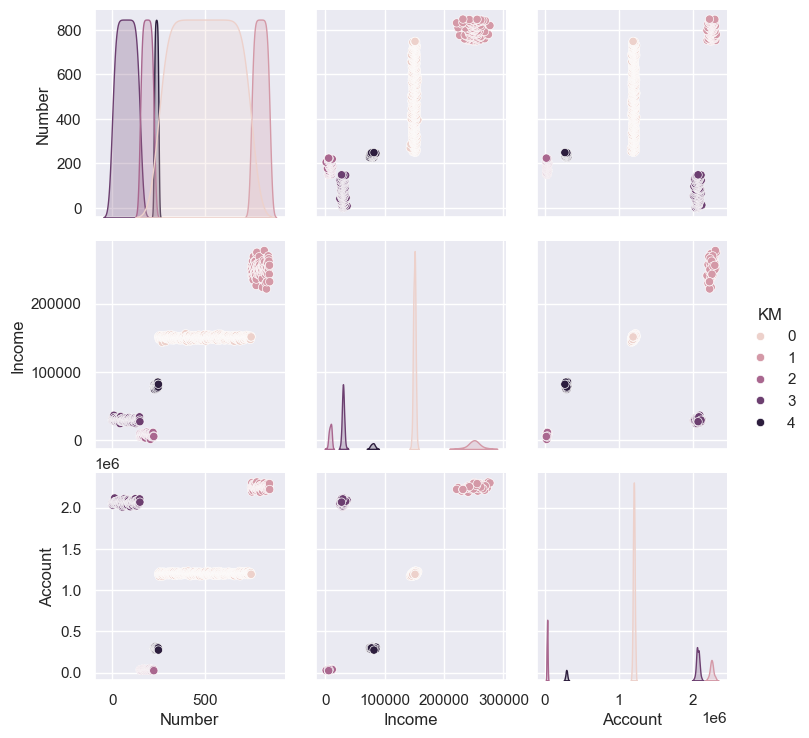

In [26]:
seaborn.pairplot(df, hue='KM')
plt.show()

Визуально каждый кластер весьма значительно отличается от прочих. Судя по графикам плотности, по показателю **Income** довольно схожи кластеры 2 и 3, а по **Account** - 1 и 2. По диаграммам разброса видно, что каждый из 5 кластеров образуют плотное множество точек, разбиение строгое ("жесткое").


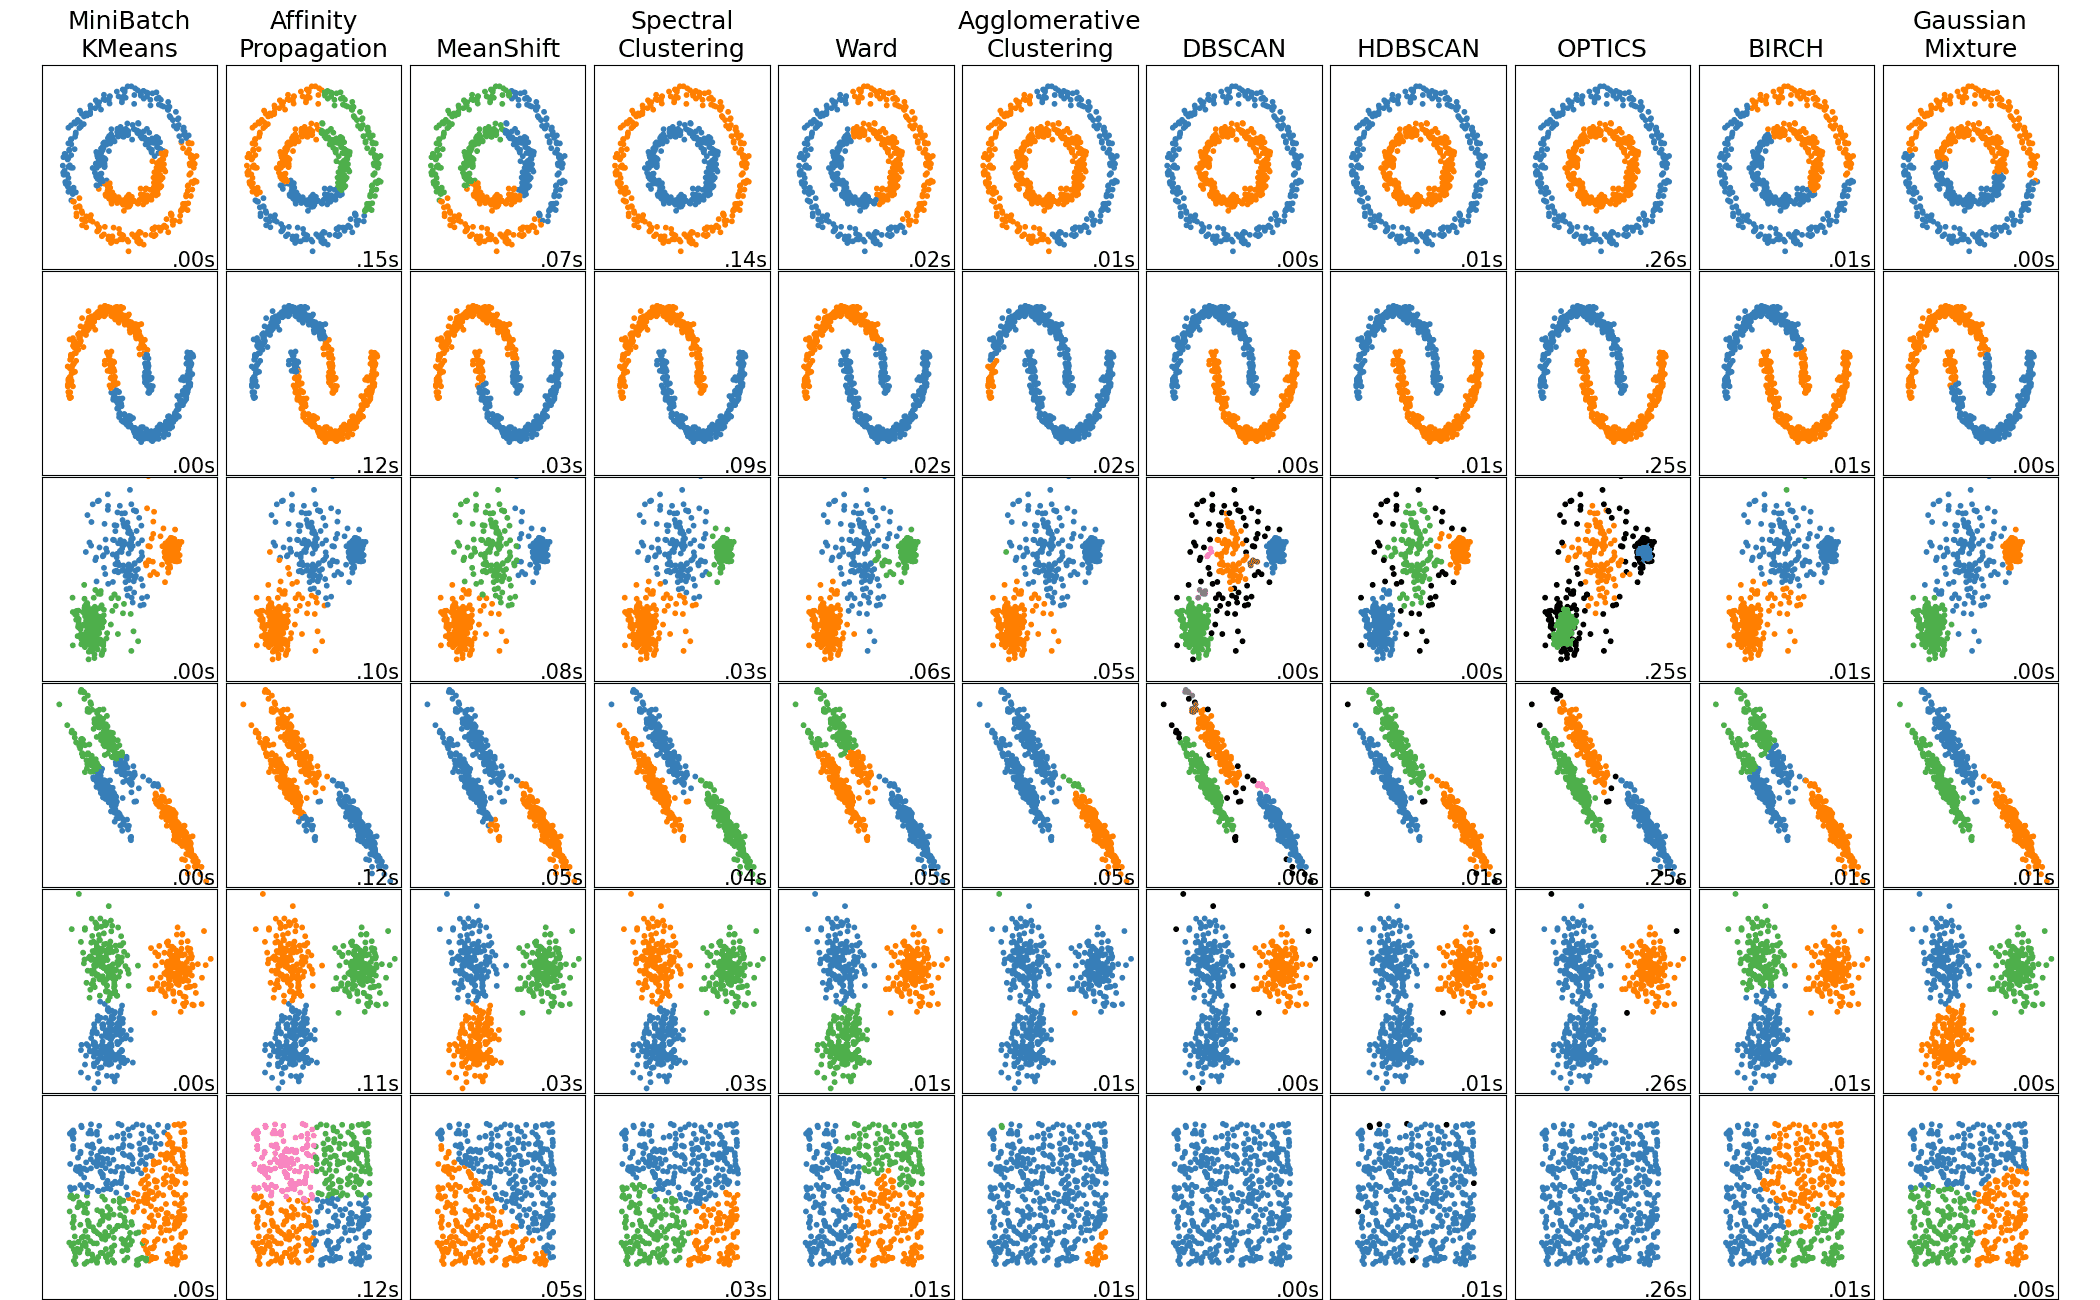

## DBSCAN

DBSCAN - алгоритм, основанный на плотности. Алгоритм группирует вместе объекты, которые расположены близко и помечает как выбросы объекты, которые находятся в областях с малой плотностью (ближайшие соседи которых лежат далеко).

Схему его  работы можно разбить на несколько этапов:

1. Начинаем с выбора случайной точки из данных.

2. Находим все точки в заданном радиусе (`eps`) от выбранной точки. Эти точки называются её соседями.

3. Если у точки достаточное количество соседей (больше минимального числа `min_samples`), то она считается ключевой точкой.

4. Если точка является ключевой, то мы расширяем кластер, добавляя всех её соседей в кластер. Также рекурсивно продолжаем этот процесс для соседей.

5. Повторяем шаги 1-4, пока все точки данных не будут обработаны.

6. В результате точки объединяются в кластеры в зависимости от того, с какими ключевыми точками они связаны.

7. Точки, которые не являются частью кластера и не имеют достаточного числа соседей, считаются шумом.

Посмотрим на результаты кластеризации при разном выборе гиперпараметров `eps` и `min_samples`.

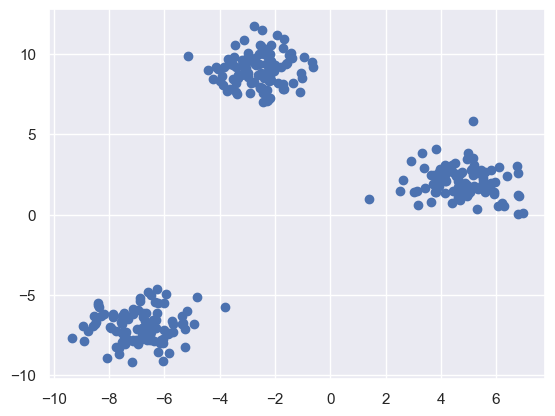

In [27]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=300, centers=3, random_state=42)
plt.scatter(X[:,0], X[:,1]);

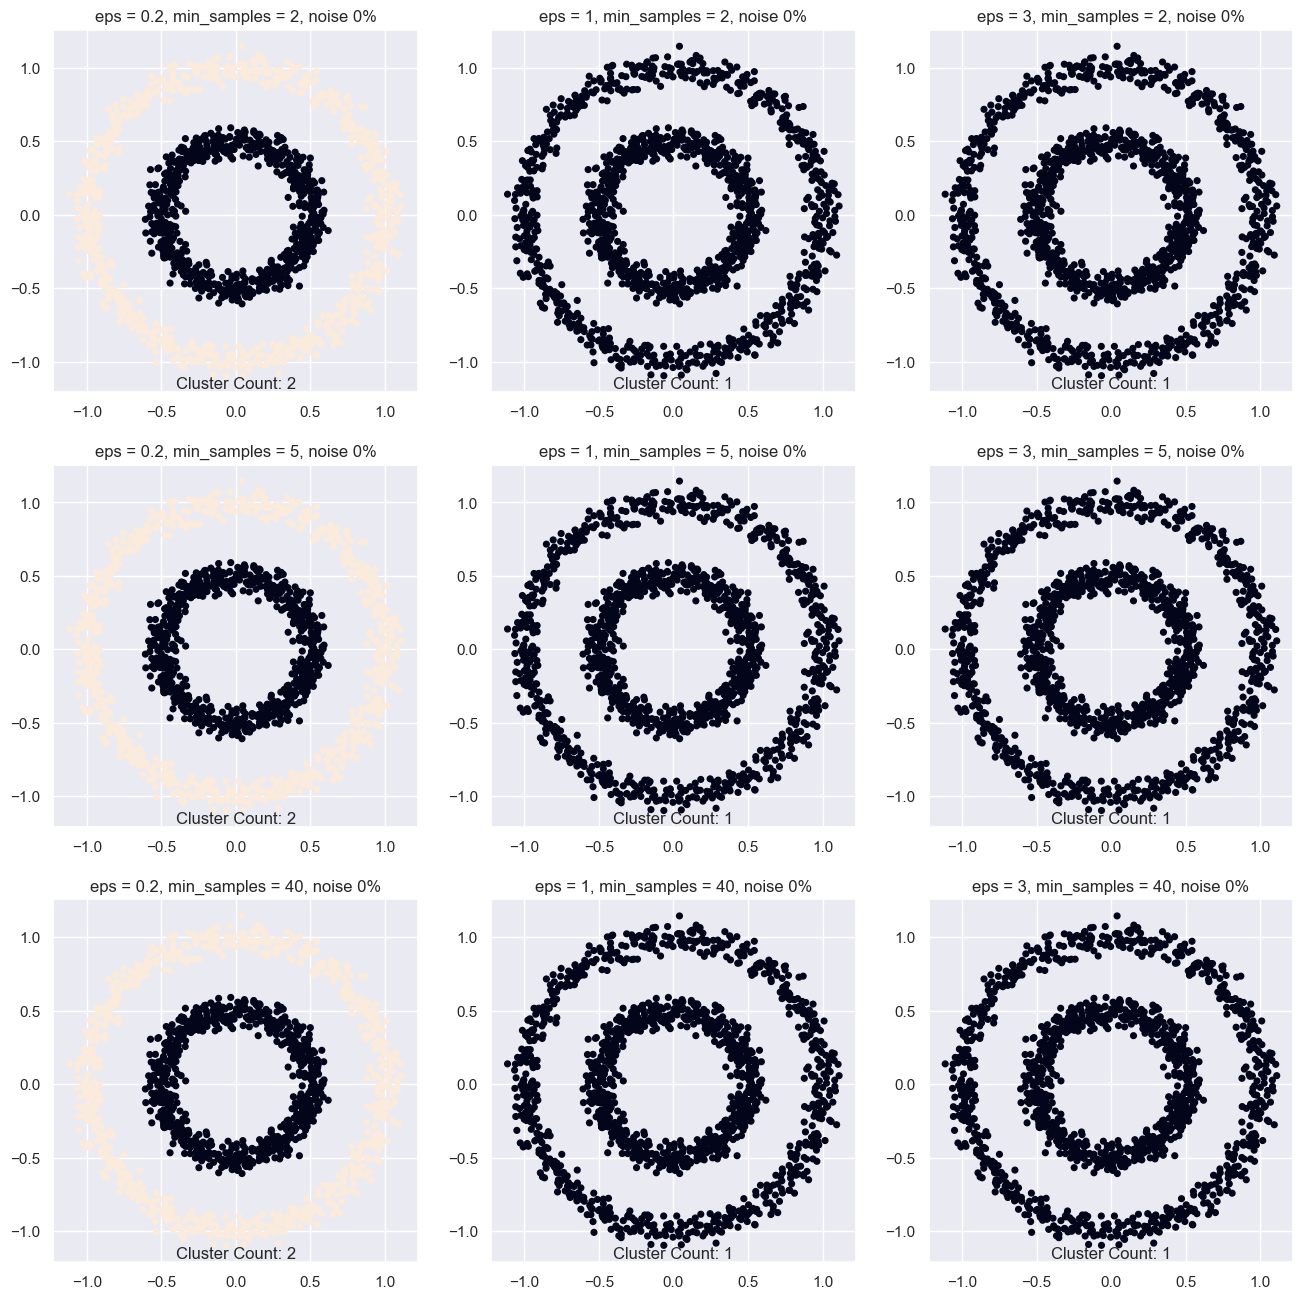

In [5]:
from sklearn.cluster import DBSCAN

plt.figure(figsize=(16, 16))
i = 1
for min_samples in [2, 5, 40]: # Итерируемся по парамерту min_samples
    for eps in [0.2, 1, 3]: # Итерируемся по размеру окружности
        dbscan = DBSCAN(eps=eps, min_samples=min_samples) # Создаем сам DBSCAN

        # Обучаем и делаем предсказания через одну строчку
        clusters = dbscan.fit_predict(X)

        # Делаем точки кластеров больше, а точки шума меньше
        plt.subplot(3, 3, i)
        plt.scatter(X[:,0], X[:,1], c=clusters, s=15 * (clusters != -1) + 2)
        plt.title('eps = {}, min_samples = {}, noise {:.0f}%'.format(
            eps, min_samples, 100. * np.sum(clusters == -1) / len(X))
        ) # Выводим все показатели

        # Выводим также количество кластеров на график
        cluster_count = len(np.unique(clusters)) - 1 if -1 in clusters \
        else len(np.unique(clusters))
        plt.text(0.5, 0.01, f'Cluster Count: {cluster_count}',
                 transform=plt.gca().transAxes, fontsize=12, ha='center')
        i += 1
plt.show()

Посмотрим как отработают алгоритмы кластеризации K-средних и DBSCAN при другой форме кластеров.

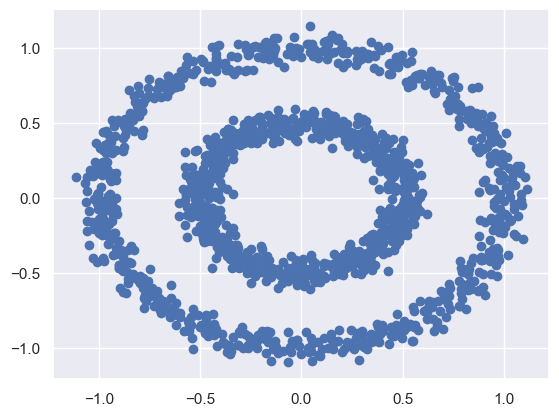

In [2]:
from sklearn.datasets import make_circles
X = make_circles(n_samples=1500, factor=.5, noise=.05, random_state=42)[0]
plt.scatter(X[:,0], X[:,1]);

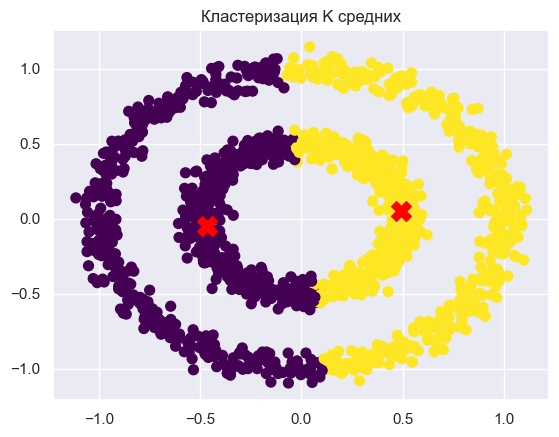

In [3]:
k_means = KMeans(n_clusters=2, n_init=10, random_state=42)
k_means = k_means.fit(X)
clusters = k_means.predict(X)

# Рисуем график с отображением центров кластеров
cluster_centers = k_means.cluster_centers_
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', s=50)
plt.title('Кластеризация K средних')
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
            c='red', s=200, marker='X')

plt.show()

## **Подбор параметров DBSCAN для идеальной кластеризации**

Переберите параметры eps, min_samples и визуально определите лучшие значения.

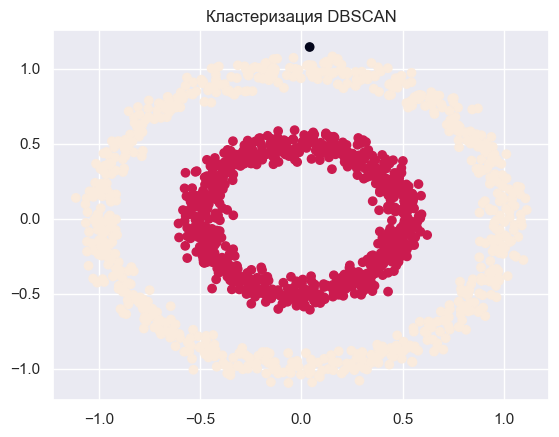

In [11]:
dbscan = DBSCAN(eps=0.10, min_samples=2)  # параметры менять здесь
clusters = dbscan.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c = clusters)
plt.title('Кластеризация DBSCAN')
plt.show()

Параметр `eps` можно подобрать и визуально, так как мы можем посмотреть на оси графика и примерно определить расстояние между внешним и внутренним кольцом.

Видно, что DBSCAN хорошо справился с задачей при верном выборе гиперпараметров `eps` и `min_samples`.
K-средних попытался выделить выпуклые области для каждого кластера, и в данном случае не смог выделить кластеры более сложной формы.

Теперь попробуем перебрать 50 значений *eps* в диапазоне 0.01 до 1. А далее построим график, который показывает количество шума и количество классов

In [12]:
# Пример работы np.linspace
np.linspace(0.01, 1.99, 20) # Создает 20 значений в диапазоне от 0.01 до 1.99

array([0.01      , 0.11421053, 0.21842105, 0.32263158, 0.42684211,
       0.53105263, 0.63526316, 0.73947368, 0.84368421, 0.94789474,
       1.05210526, 1.15631579, 1.26052632, 1.36473684, 1.46894737,
       1.57315789, 1.67736842, 1.78157895, 1.88578947, 1.99      ])

In [13]:
from sklearn.cluster import DBSCAN
import tqdm # Библиотека для отрисовки progress бара

epss = []
noises = []
counts = []
for eps in tqdm.tqdm(np.linspace(0.01, 1, 50)): # Итерируемся по значениям eps
    dbscan = DBSCAN(eps=eps, min_samples=3)

    # Сохраняем рассчитанные значения
    clusters = dbscan.fit_predict(X)
    epss.append(eps)
    counts.append(len(set(clusters)))
    noises.append(100. * np.sum(clusters == -1) / len(X))

100%|██████████| 50/50 [00:01<00:00, 48.12it/s]


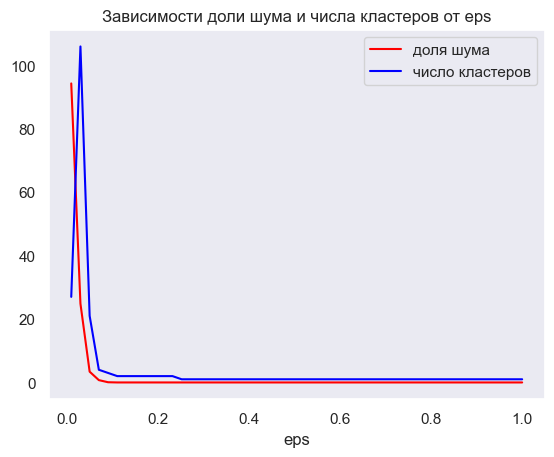

In [14]:
plt.plot(epss, noises, c='red', label='доля шума')
plt.plot(epss, counts, c='blue', label='число кластеров')

plt.title("Зависимости доли шума и числа кластеров от eps")
plt.grid()
plt.xlabel('eps')
plt.legend()
plt.show()